Imports

In [123]:
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix

from pyts.approximation import SymbolicAggregateApproximation

from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.circuit.library import zz_feature_map, pauli_feature_map



In [124]:
CONFIG = {
    "window_size": 5,
    "alphabet_size": 3,   # ABC
    "train_frac": 0.8,
    "reps_max": 3,
    "n_points": 320,
    "noise_std": 0.10,
    "delta_thresh": 0.04,
    "seed_data": 123,
    "seed_qsvc": 12345,
}


Data + SAX dataset

In [125]:
import numpy as np
from pyts.approximation import SymbolicAggregateApproximation

def make_dataset_abc(
    *,
    window_size,
    alphabet_size,
    n_points,
    noise_std,
    delta_thresh,
    seed,
    step=1,
):
    rng = np.random.default_rng(seed)

    # noisy sine
    t = np.linspace(0, 6 * np.pi, n_points)
    ts = np.sin(t) + rng.normal(0.0, noise_std, size=n_points)

    # plot the time series
    import matplotlib.pyplot as plt
    plt.plot(t, ts)
    plt.title("Noisy Sine Wave Time Series")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.show()

    # sliding windows
    X = []
    y = []
    for i in range(0, len(ts) - window_size - step):
        X.append(ts[i : i + window_size])

        delta = ts[i + window_size + step - 1] - ts[i + window_size - 1]
        if delta > delta_thresh:
            y.append(2)   # up
        elif delta < -delta_thresh:
            y.append(0)   # down
        else:
            y.append(1)   # flat

    X = np.asarray(X)
    y = np.asarray(y)

    sax = SymbolicAggregateApproximation(
        n_bins=alphabet_size,
        strategy="uniform"
    )
    X_sax = sax.fit_transform(X)

    return X_sax, y


Utilities (diagnostics, mapping, split)

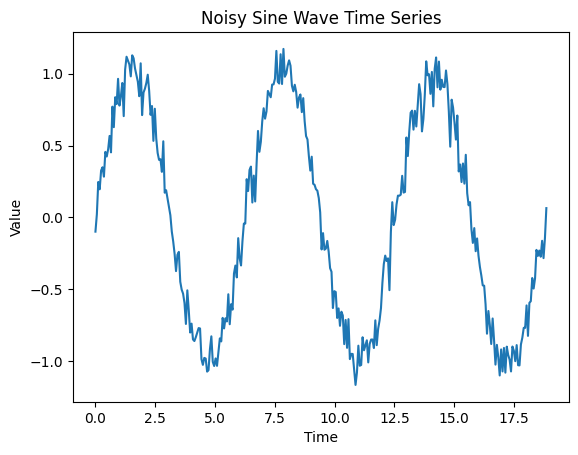

In [126]:
X_sax, y = make_dataset_abc(
    window_size=CONFIG["window_size"],
    alphabet_size=CONFIG["alphabet_size"],
    n_points=CONFIG["n_points"],
    noise_std=CONFIG["noise_std"],
    delta_thresh=CONFIG["delta_thresh"],
    seed=CONFIG["seed_data"],
)


def sax_to_angles(X_sax, eps=1e-3):
    X_sax = np.asarray(X_sax).astype(str)
    alphabet = sorted(np.unique(X_sax.reshape(-1)).tolist())
    k = len(alphabet)
    if k < 2:
        raise ValueError(f"Alphabet too small ({k}).")

    angles = np.linspace(eps, np.pi - eps, k)
    mapping = {sym: ang for sym, ang in zip(alphabet, angles)}

    X = np.empty(X_sax.shape, dtype=float)
    for sym in np.unique(X_sax):
        if sym not in mapping:
            raise ValueError(f"Unknown symbol '{sym}'.")
        X[X_sax == sym] = mapping[sym]

    return X, mapping

def uniqueness_ratio(X_sax):
    X_sax = np.asarray(X_sax)
    words = ["".join(row.astype(str).tolist()) for row in X_sax]
    return len(set(words)) / max(1, len(words))

def time_split(X, y, train_frac=0.8):
    n = len(X)
    split = int(train_frac * n)
    if split <= 1 or split >= n:
        raise ValueError("Train/test split produced empty train or test.")
    return X[:split], X[split:], y[:split], y[split:]

def encode_labels(y):
    le = LabelEncoder()
    return le.fit_transform(y), le

def summarize_run(name, y_true, y_pred, le=None):
    acc = accuracy_score(y_true, y_pred)
    print(f"{name} acc={acc:.3f}")
    print(confusion_matrix(y_true, y_pred))
    if le is not None:
        print("classes:", list(le.classes_))
    return acc


Classical baselines (Linear + RBF)

In [127]:
def run_classical_baselines(X_train, X_test, y_train, y_test):
    rbf = make_pipeline(StandardScaler(), SVC(kernel="rbf", gamma="scale"))

    rbf.fit(X_train, y_train)

    y_pred_rbf = rbf.predict(X_test)

    acc_rbf = summarize_run("RBF-SVC", y_test, y_pred_rbf)

    return {"RBF-SVC": acc_rbf}


Quantum kernel QSVC (reps = 1 or 2)

In [128]:
def run_qsvc(X_train, X_test, y_train, y_test, reps=1, seed=12345):
    algorithm_globals.random_seed = seed

    zz_fm = zz_feature_map(feature_dimension=X_train.shape[1], reps=reps, entanglement="full")
    sampler = Sampler() 
    fidelity = ComputeUncompute(sampler=sampler)
    qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=zz_fm)

    model = QSVC(quantum_kernel=qkernel)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = summarize_run(f"QSVC(reps={reps})", y_test, y_pred)
    return acc


VQC and VQC with ZZ feature map (reps = 1 or 2)

In [129]:
import numpy as np

from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.algorithms.regressors import VQR

# primitives (statevector exact)
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.primitives import StatevectorEstimator as Estimator


def run_vqc(X_train, X_test, y_train, y_test, reps=1, seed=12345, maxiter=100):
    """Minimal VQC baseline comparable to run_qsvc style."""
    algorithm_globals.random_seed = seed

    # feature map + ansatz
    fm = zz_feature_map(feature_dimension=X_train.shape[1], reps=reps, entanglement="full")
    ansatz = real_amplitudes(num_qubits=X_train.shape[1], reps=2, entanglement="full")

    optimizer = COBYLA(maxiter=maxiter)
    sampler = Sampler()

    model = VQC(feature_map=fm, ansatz=ansatz, optimizer=optimizer, sampler=sampler)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = summarize_run(f"VQC(fm_reps={reps})", y_test, y_pred)
    return acc


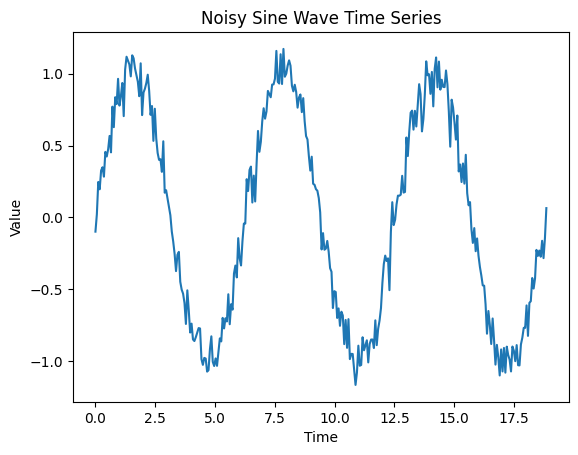

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



=== RUN ===
window=5 | alphabet=3 | reps(VQC)=3
n=314 | train/test=251/63 | majority=0.414 | random=0.333
class_counts={0:130, 1:67, 2:117} | unique_ratio=0.414
top_words=[('ccbaa', 10), ('aaccc', 8), ('caaaa', 7), ('cccba', 7), ('abccc', 7)]
RBF-SVC acc=0.587
[[20  0 11]
 [ 3  0  5]
 [ 7  0 17]]
VQC(fm_reps=3) acc=0.444
[[28  3  0]
 [ 8  0  0]
 [22  2  0]]
QSVC(reps=1) acc=0.603
[[22  0  9]
 [ 5  0  3]
 [ 8  0 16]]
SUMMARY | w=5 a=3 uniq=0.414 | RBF=0.587 | QSVC(r1)=0.603 | VQC(r3)=0.444


In [130]:
from collections import Counter
import numpy as np

def sax_word_stats(X_sax, top_k=5):
    X_sax = np.asarray(X_sax)
    words = ["".join(row.astype(str).tolist()) for row in X_sax]
    uniq = len(set(words))
    return {
        "n": len(words),
        "unique": uniq,
        "unique_ratio": uniq / max(1, len(words)),
        "top_words": Counter(words).most_common(top_k),
    }

def _fmt_counts(counter_obj):
    items = sorted(counter_obj.items(), key=lambda kv: kv[0])
    return "{" + ", ".join([f"{k}:{v}" for k, v in items]) + "}"

def run_report(config):
    # --- unpack config (single source of truth) ---
    window_size   = config["window_size"]
    alphabet_size = config["alphabet_size"]
    train_frac    = config["train_frac"]
    seed_data     = config["seed_data"]
    seed_model    = config["seed_qsvc"]
    reps_vqc      = config.get("reps_max", 1)
    maxiter_vqc   = config.get("maxiter_vqc", 50)

    # 1) dataset
    X_sax, y = make_dataset_abc(
        window_size=window_size,
        alphabet_size=alphabet_size,
        n_points=config["n_points"],
        noise_std=config["noise_std"],
        delta_thresh=config["delta_thresh"],
        seed=seed_data,
    )

    # 2) representation diagnostics
    y = np.asarray(y)
    counts = Counter(y.tolist())
    majority = max(counts.values()) / len(y)
    stats = sax_word_stats(X_sax)

    # 3) numeric features + split
    X_angles, _ = sax_to_angles(X_sax)
    y_enc, le = encode_labels(y)
    X_train, X_test, y_train, y_test = time_split(X_angles, y_enc, train_frac=train_frac)

    random_base = 1.0 / len(le.classes_)

    # --- Header ---
    print("\n=== RUN ===")
    print(f"window={window_size} | alphabet={alphabet_size} | reps(VQC)={reps_vqc}")
    print(f"n={len(y)} | train/test={len(y_train)}/{len(y_test)} | "
          f"majority={majority:.3f} | random={random_base:.3f}")
    print(f"class_counts={_fmt_counts(counts)} | unique_ratio={stats['unique_ratio']:.3f}")
    print(f"top_words={stats['top_words']}")

    # 4) classical baselines
    base = run_classical_baselines(X_train, X_test, y_train, y_test)
    acc_rbf = base["RBF-SVC"]

    # 5) VQC (simple variational baseline)
    vqc_acc = run_vqc(
        X_train, X_test, y_train, y_test,
        reps=reps_vqc, seed=seed_model, maxiter=maxiter_vqc
    )

    # 6) QSVC (quantum kernel, fixed reps=1)
    qsvc_acc = run_qsvc(
        X_train, X_test, y_train, y_test,
        reps=1, seed=seed_model
    )

    # --- One-line summary ---
    print(
        "SUMMARY | "
        f"w={window_size} a={alphabet_size} uniq={stats['unique_ratio']:.3f} | "
        f"RBF={acc_rbf:.3f} | "
        f"QSVC(r1)={qsvc_acc:.3f} | "
        f"VQC(r{reps_vqc})={vqc_acc:.3f}"
    )

    return {
        "config": dict(config),
        "stats": stats,
        "class_counts": dict(counts),
        "baselines": base,
        "vqc_acc": vqc_acc,
        "qsvc_acc": qsvc_acc,
    }

out = run_report(CONFIG)
